In [ ]:
import os
import time
import random
import warnings
from datetime import date
import gc

import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
from lxml import etree # type: ignore <- pylance milně hlásí chybu
from pathlib import Path
import time
import sys
import polars as pl
import polars.selectors as cs
import json
import pickle
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patheffects as path_effects
from ydata_profiling import ProfileReport
import geopandas as gpd


current_dir = Path(__file__).resolve().parent if "__file__" in locals() else Path.cwd()
sys.path.append(str(current_dir.parent))
from utils import *
from schemas import *
from clean import *
from visualisation_utils import *

pl.Config.set_tbl_cols(-1)
os.chdir(r'E:\CVUT_BAP')
# os.chdir(r'C:\Users\adamp\Projects\CVUT_BAP')
SEED=42
PRINT = True
DATA_PATH = r"kod\data\processed\mereni.parquet"
TEMP_PATH = r"kod\data\processed\mereni.tmp.parquet"

# Nacteni dat

In [2]:
lf_mereni = pl.scan_parquet(r"kod\data\processed\mereni_tmp.parquet")
lf_prohlidky = pl.scan_parquet(r"kod\data\processed\prohlidky_clean.parquet")
df = lf_mereni.join(lf_prohlidky, how='inner', on='CisloProtokolu').collect()

df_benzin = pl.read_parquet(r"kod\data\processed\normalized_benzin.parquet")
df_nafta = pl.read_parquet(r"kod\data\processed\normalized_nafta.parquet")

# Casove rady tykajici se pruchodnosti

## Vyvoj uspesnosti prohlidek

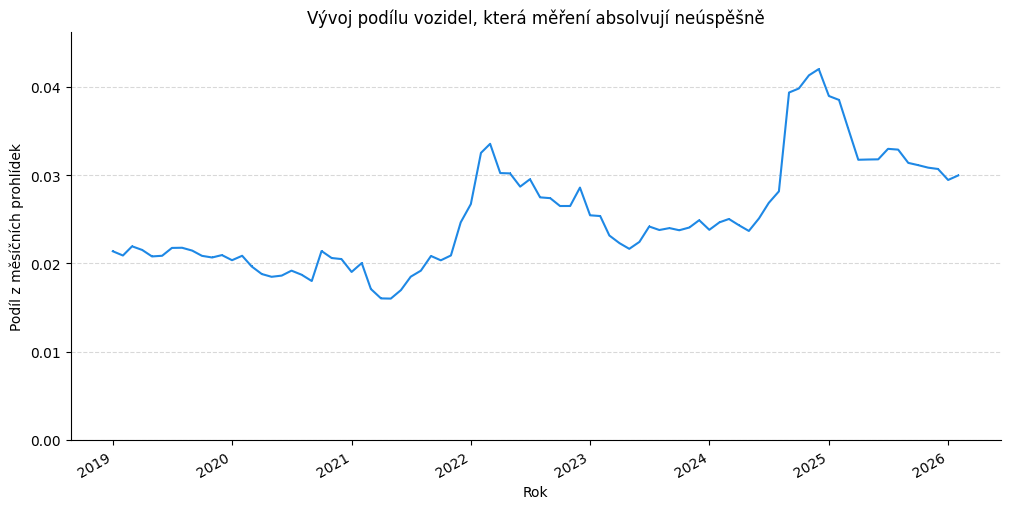

In [25]:
time_series_monthly_expr(df, 'DatumProhlidky', (1 - (pl.col('Vysledek_Vyhovuje') == True).fill_null(False).mean()), 'Vývoj podílu vozidel, která měření absolvují neúspěšně', 'Podíl z měsíčních prohlídek', 'kod/casove_rady/vyvoj_pruchodnosti.svg', decimals=2)

## Rozdil mezi nejprisnejsimi a nejvolnejsimi stanicemi

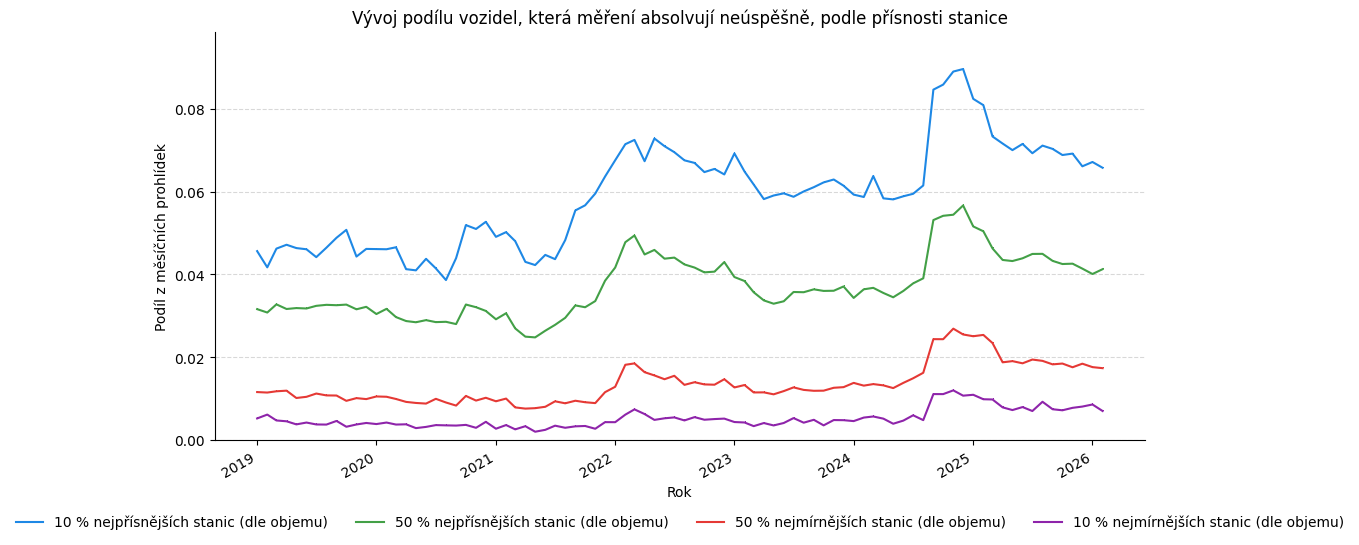

In [26]:
# Agregace neúspěšnosti a objemu měření pro jednotlivé stanice
df_stations = df.group_by("Prohlidka_Stanice_Cislo").agg(
    celkem=pl.len(),
    nevyhovuje=pl.col("Vysledek_Vyhovuje").is_null().sum()
).with_columns(
    neuspesnost=pl.col("nevyhovuje") / pl.col("celkem")
)

# Výpočet limitů pro stanovení podílu na celkovém objemu dat
limit_10 = df.height * 0.10
limit_50 = df.height * 0.50

# Funkce pro výběr stanic naplňujících objemový limit podle míry neúspěšnosti
def get_stations(limit, desc_neuspesnost):
    return (
        df_stations.sort(["neuspesnost", "celkem"], descending=[desc_neuspesnost, True])
        .with_columns(cum_celkem=pl.col("celkem").cum_sum())
        .filter(pl.col("cum_celkem") <= limit)
        .get_column("Prohlidka_Stanice_Cislo")
        .to_list()
    )

# Generování seznamů stanic pro nejhorší a nejlepší segmenty trhu
worst_10_stations = get_stations(limit_10, desc_neuspesnost=True)
best_10_stations = get_stations(limit_10, desc_neuspesnost=False)
worst_50_stations = get_stations(limit_50, desc_neuspesnost=True)
best_50_stations = get_stations(limit_50, desc_neuspesnost=False)

# Funkce pro tvorbu agregačního výrazu počítajícího podíl neúspěšných prohlídek
def create_expr(stations_list, alias_name):
    return (
        pl.col("Vysledek_Vyhovuje").filter(pl.col("Prohlidka_Stanice_Cislo").is_in(stations_list)).is_null().sum() /
        pl.col("Prohlidka_Stanice_Cislo").filter(pl.col("Prohlidka_Stanice_Cislo").is_in(stations_list)).len()
    ).alias(alias_name)

# Sestavení finálních výrazů pro měsíční časové řady v grafu
exprs = [
    create_expr(worst_10_stations, "10 % nejpřísnějších stanic (dle objemu)"),
    create_expr(worst_50_stations, "50 % nejpřísnějších stanic (dle objemu)"),
    create_expr(best_50_stations, "50 % nejmírnějších stanic (dle objemu)"),
    create_expr(best_10_stations, "10 % nejmírnějších stanic (dle objemu)"),
]

time_series_monthly_expr(df, 'DatumProhlidky', exprs, 'Vývoj podílu vozidel, která měření absolvují neúspěšně, podle přísnosti stanice', 'Podíl z měsíčních prohlídek', 'kod/casove_rady/vyvoj_pruchodnosti_podle_stanice.svg', decimals=2)

# Pocty dennich mereni techniku

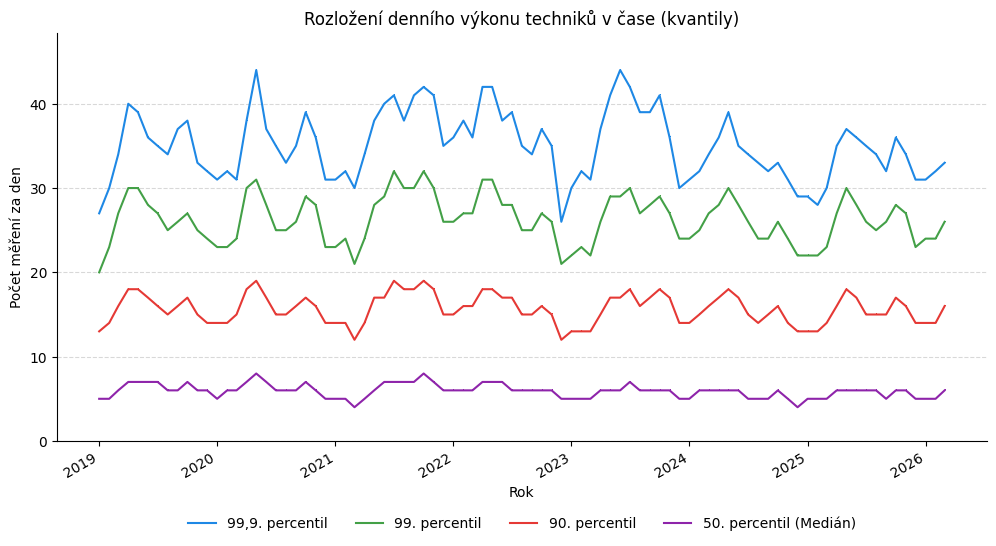

In [ ]:
# Příprava datových sloupců pro měsíc a konkrétní den
df_work = df.filter(pl.col("DatumProhlidky").is_not_null()).with_columns(
    pl.col("DatumProhlidky").dt.truncate("1mo").alias("_ts_month"),
    pl.col("DatumProhlidky").dt.date().alias("_date")
)

# Seskupení na úroveň "jeden technik v jeden konkrétní den"
# Tím získáme seznam všech uskutečněných denních směn a počtu prohlídek v nich
df_tech_daily = df_work.group_by(["_ts_month", "Emise_OdpovednaOsoba", "_date"]).agg(
    denni_pocet_prohlidek=pl.len()
)

# Agregace denních výkonů do kvantilů za každý měsíc
df_quantiles = df_tech_daily.group_by("_ts_month").agg([
    pl.col("denni_pocet_prohlidek").quantile(0.999).alias("99,9. percentil"),
    pl.col("denni_pocet_prohlidek").quantile(0.99).alias("99. percentil"),
    pl.col("denni_pocet_prohlidek").quantile(0.90).alias("90. percentil"),
    pl.col("denni_pocet_prohlidek").median().alias("50. percentil (Medián)"),
])

# Vykreslení
time_series_monthly_expr(
    df=df_quantiles, 
    time_col="_ts_month", 
    exprs=None,                
    title="Rozložení denního výkonu techniků v čase (kvantily)", 
    y_title="Počet měření za den",
    decimals=0,
    save_path='kod/casove_rady/vykonnost_techniku.svg'
)

# Vyvoj delky prohlidky

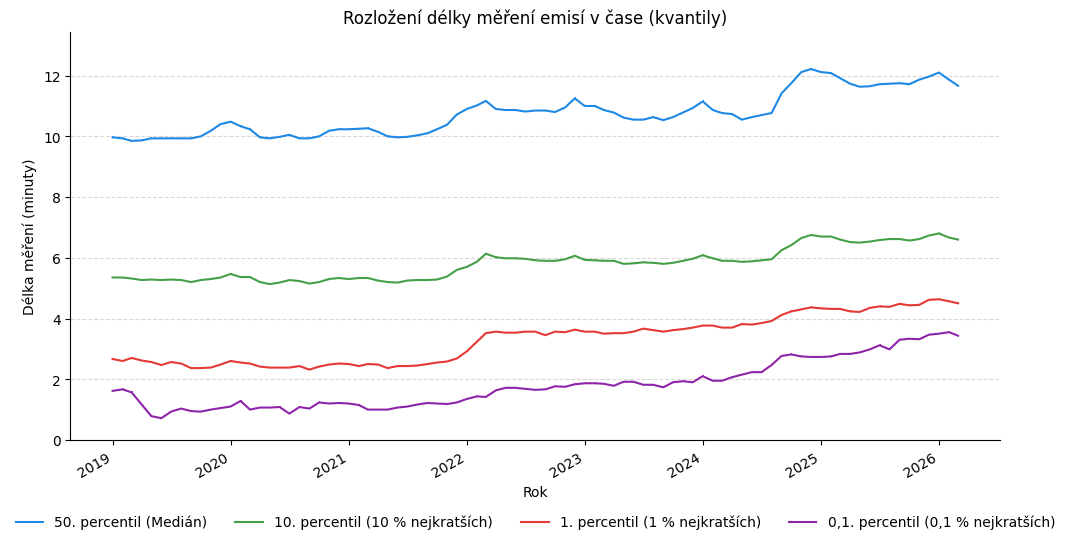

In [62]:
# Příprava dat: filtrace prázdných časů, zařazení do měsíce a výpočet délky v minutách
# Použití total_seconds() / 60 zajišťuje desetinnou přesnost na rozdíl od celočíselného total_minutes()
df_duration = df.filter(
    pl.col("Emise_Zahajeni").is_not_null() & 
    pl.col("Emise_Ukonceni").is_not_null() &
    pl.col("Vysledek_Vyhovuje").is_not_null()
).with_columns(
    pl.col("Emise_Zahajeni").dt.truncate("1mo").alias("_ts_month"),
    ((pl.col("Emise_Ukonceni") - pl.col("Emise_Zahajeni")).dt.total_seconds() / 60.0).alias("delka_mereni_min")
)

# Volitelné, ale doporučené: odfiltrování zjevných datových chyb (např. záporný čas nebo měření nad 3 hodiny)
df_duration = df_duration.filter(
    (pl.col("delka_mereni_min") > 0) & 
    (pl.col("delka_mereni_min") < 180)
)

# Agregace délek všech měření do kvantilů v jednotlivých měsících
df_quantiles_duration = df_duration.group_by("_ts_month").agg([
    pl.col("delka_mereni_min").median().alias("50. percentil (Medián)"),
    pl.col("delka_mereni_min").quantile(0.10).alias("10. percentil (10 % nejkratších)"),
    pl.col("delka_mereni_min").quantile(0.01).alias("1. percentil (1 % nejkratších)"),
    pl.col("delka_mereni_min").quantile(0.001).alias("0,1. percentil (0,1 % nejkratších)"),
])

# Zavolání vizualizační funkce s hotovými kvantily
time_series_monthly_expr(
    df=df_quantiles_duration, 
    time_col="_ts_month", 
    exprs=None,                
    title="Rozložení délky měření emisí v čase (kvantily)", 
    y_title="Délka měření (minuty)",
    decimals=0,
    save_path='kod/casove_rady/delka_prohlidky.svg'
)

# Meření mimo povolené limity

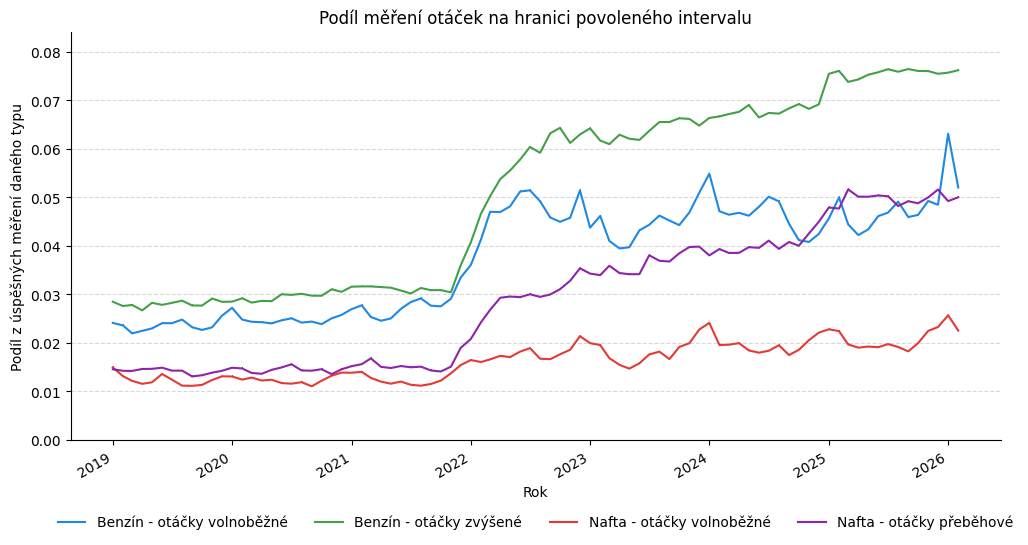

In [63]:
# Společná příprava dat a funkcí (vykoná se pouze jednou)
df_benzin = pl.read_parquet(r"kod\data\processed\normalized_benzin.parquet")
df_nafta = pl.read_parquet(r"kod\data\processed\normalized_nafta.parquet")
df_base = pl.concat([df_benzin, df_nafta], how="diagonal")

if df_base.schema["Date"] == pl.String:
    df_base = df_base.with_columns(pl.col("Date").str.to_datetime())

epsilon = 0.01

# Pomocná funkce pro tvorbu výrazu (aby se kód neopakoval)
def get_suspect_expr(col):
    clean_name = (
        col.replace('Benzin_OtackyVolnobezne_N_Hodnota_Norm', 'Benzín - otáčky volnoběžné')
           .replace('Benzin_OtackyZvysene_N_Hodnota_Norm' , 'Benzín - otáčky zvýšené')
           .replace('Nafta_MereniPrumer_OtackyVolnobezne_Hodnota_Norm', 'Nafta - otáčky volnoběžné')
           .replace('Nafta_MereniPrumer_OtackyPrebehove_Hodnota_Norm', 'Nafta - otáčky přeběhové')
    )
    is_suspect = pl.col(col).is_between(-epsilon, epsilon) | pl.col(col).is_between(1 - epsilon, 1 + epsilon)
    return (is_suspect.fill_null(False).sum() / pl.col(col).is_not_null().sum()).alias(clean_name)

cols_otacky = [
    'Benzin_OtackyVolnobezne_N_Hodnota_Norm', 
    'Benzin_OtackyZvysene_N_Hodnota_Norm', 
    'Nafta_MereniPrumer_OtackyVolnobezne_Hodnota_Norm', 
    'Nafta_MereniPrumer_OtackyPrebehove_Hodnota_Norm'
]
cols_otacky_exist = [c for c in cols_otacky if c in df_base.columns]
exprs_otacky = [get_suspect_expr(c) for c in cols_otacky_exist]

time_series_monthly_expr(
    df=df_base, 
    time_col="Date", 
    exprs=exprs_otacky,
    title="Podíl měření otáček na hranici povoleného intervalu",
    y_title="Podíl z úspěšných měření daného typu",
    decimals=2,
    save_path='kod/casove_rady/mereni_krajni_hodnoty_otacky.svg'
)

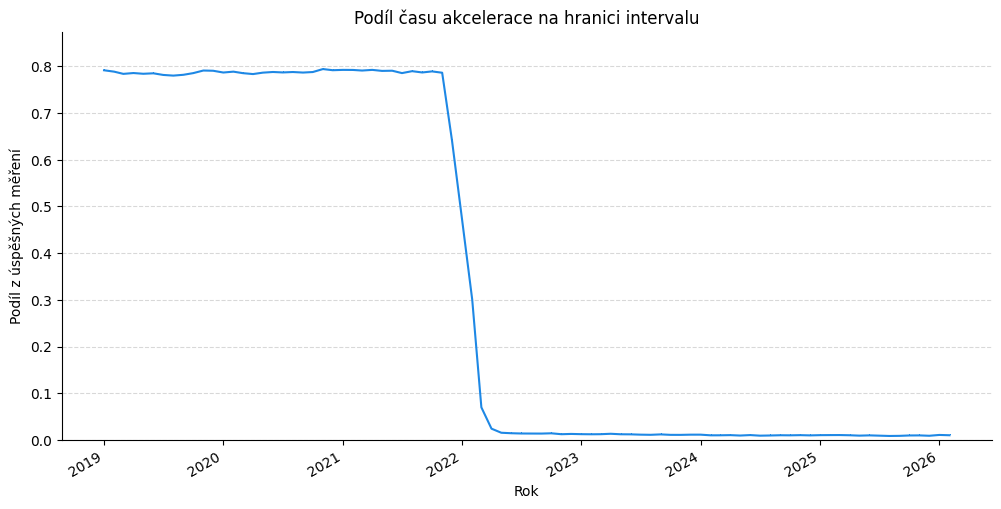

In [64]:
col_akcelerace = 'Nafta_MereniPrumer_CasAkcelerace_Hodnota_Norm'

if col_akcelerace in df_base.columns:
    exprs_akcelerace = [get_suspect_expr(col_akcelerace)]
    
    time_series_monthly_expr(
        df=df_base, 
        time_col="Date", 
        exprs=exprs_akcelerace,
        title="Podíl času akcelerace na hranici intervalu",
        y_title="Podíl z úspěšných měření",
        decimals=1,
        save_path='kod/casove_rady/mereni_krajni_hodnoty_akcelerace.svg'
    )

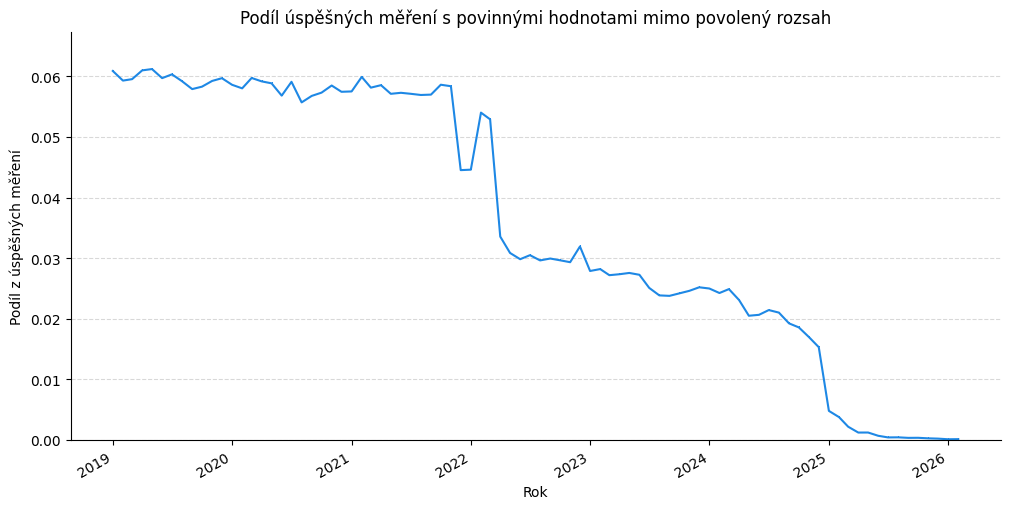

In [65]:
norm_cols = [c for c in df_base.columns if c.endswith('_Norm')]
out_of_bounds_exprs = [(pl.col(c) < 0) | (pl.col(c) > 1) for c in norm_cols]

expr_anomalies = (
    pl.any_horizontal(out_of_bounds_exprs).fill_null(False).sum() / pl.len()
).alias("CELKOVÉ Anomálie (mimo rozsah 0-1)")

time_series_monthly_expr(
    df=df_base, 
    time_col="Date", 
    exprs=[expr_anomalies],
    title="Podíl úspěšných měření s povinnými hodnotami mimo povolený rozsah", 
    y_title="Podíl z úspěšných měření",
    decimals=2,
    save_path='kod/casove_rady/mereni_anomalie_celkove.svg'
)